# Lab 4. Nuclear radiation experiment
Igor Gitelman, 2024, v0.1

We start over with importing the needed module.

In [11]:
import matplotlib.pyplot as plt  # for plotting figures and setting their properties
import numpy as np  # math functions
import pandas as pd  # handling data structures (loaded from files)
import scipy
from scipy.signal import (
    find_peaks as find_peaks,
)  # Find peaks inside a signal based on peak properties.

# Background radiation

Let's measure the background rate, and collect the "Elapsed time", and "Counts". and calculate the rate, pay attention to the measurement error.

In [12]:
time = 100  # s
Counts = 52  # put your measured value
Back_Rate = Counts / time  # Counts per second Cps
print("The background rate: ", Back_Rate)

The background rate:  0.52


Take the names of the columns, and create relevant variables

# The cumulant statistics.

Do not forget to estimate the error on these values.

In [13]:
df = pd.read_csv("dan_stats2.tsv", header=9, sep="\t+", engine="python")
counts = df["Counts"]
time = df["Time"]


def parse_file(filename):
    df = pd.read_csv(filename, header=9, sep="\t+", engine="python")
    return df["Time"], df["Counts"]


Rate = counts / time  # Cps


# k1, mean
def mean_f(data):
    return np.sum(data) / len(data)


# k2 , var
def var(data):
    M = mean_f(data)
    length = len(data)
    var = []
    for n in data:
        var.append((n - M) ** 2)
    return np.sum(var) / (length - 1)


# k3,
def k3(data):
    M = mean_f(data)
    length = len(data)
    k3 = []
    for n in data:
        k3.append((n - M) ** 3)
    return np.sum(k3) / (length - 1)


print(
    f"k1 = {mean_f(counts):.2f}",
    f" k2 = {var(counts):.2f}",
    f" k3 = {k3(counts):.2f}",
)

k1 = 3.51  k2 = 3.37  k3 = 4.21


# Histogram

plot the histogram of your obtained data, compare it with a theoretical Poisson distribution with the same mean

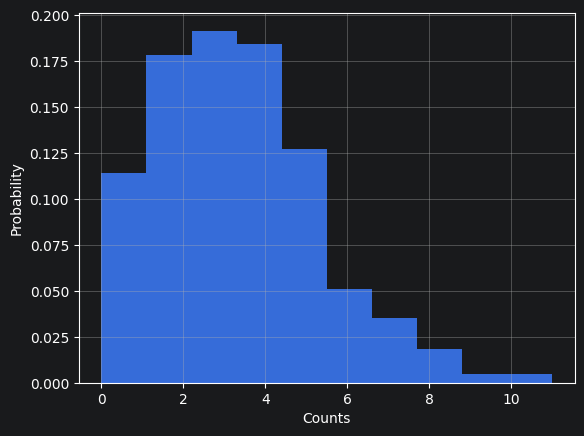

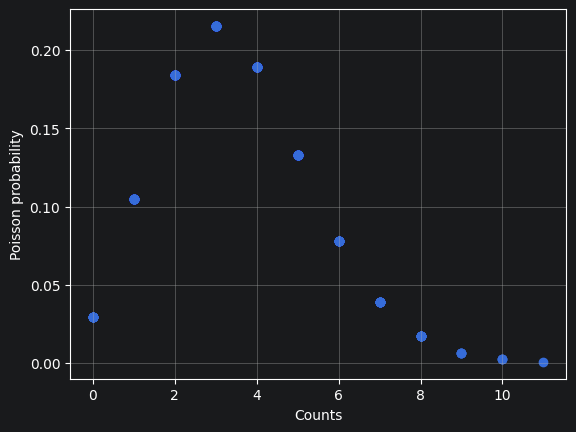

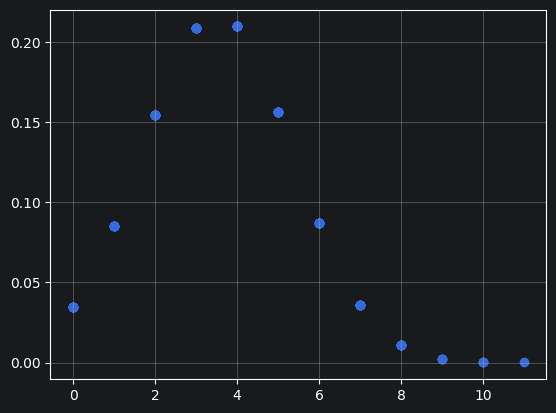

In [14]:
# plt.figure(dpi=200) # Define new figure, and set "Dots per Inch" or "dpi"
co, bins = np.histogram(counts, bins=14, density=True)


# Define the Poisson probability function
def poisson_pf(k, lam):
    return lam**k / scipy.special.gamma(k + 1) * np.exp(-lam)


lam = mean_f(counts)
var_ = var(counts)
pois = poisson_pf(counts, lam)
plt.grid()
plt.hist(counts, bins=10, density=True)
plt.xlabel("Counts")
plt.ylabel("Probability")

plt.figure()
plt.scatter(counts, pois)
plt.grid(True)
plt.xlabel("Counts")
plt.ylabel("Poisson probability")


def gaussian_pf(x, mu, sigma):
    return (
        1
        / (np.sqrt(2 * np.pi) * sigma)
        * np.exp(-np.power(x - mu, 2.0) / (2 * np.power(sigma, 2.0)))
    )


plt.figure()
plt.scatter(counts, gaussian_pf(counts, lam, np.sqrt(var_)))
plt.grid()

# Attenuation of β-radiation and estimation of maximal β-particle energy

You need to estimate the Tenth-Value Layer (TLV) for three Sources Tl, Sr, Co.

You need to measure for each source
1. The thickness of the aluminum
2. The measurement time
3. Number of detections "Counts"
* Don't forget to place the error bars.
* So you get the $rate = \frac{Counts}{Time} $ as function of aluminum thickness.


Now we measure the TLV from here.

0      7.0
1     18.0
2     14.0
3      8.0
4     12.0
5     10.0
6      7.0
7     11.0
8     13.0
9      6.0
10    15.0
11    19.0
12    17.0
13    16.0
14     9.0
15     9.0
16    13.0
17     8.0
18    13.0
19    10.0
20     6.0
21     9.0
22     9.0
23     6.0
24    13.0
25    11.0
26    13.0
27    11.0
28    14.0
29    15.0
30    13.0
31     8.0
32    16.0
33    10.0
34     9.0
35    13.0
36    19.0
37    13.0
38    15.0
39    13.0
40    11.0
41    15.0
42    11.0
43    12.0
44    16.0
45    16.0
46     7.0
47    12.0
48    13.0
49    12.0
50     5.0
51    10.0
52    16.0
53    12.0
54    20.0
55    14.0
56    11.0
57     9.0
58    10.0
59    11.0
dtype: float64


ValueError: x and y must be the same size

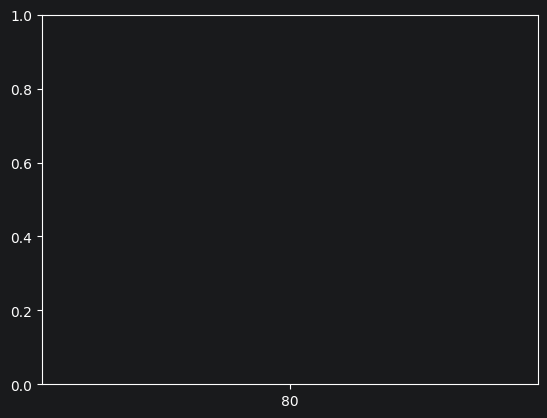

In [16]:
from pathlib import Path


class BetaMeasurement:
    def __init__(self, thickness, filename):
        self.thickness = thickness
        self.time, self.counts = parse_file(filename)
        self.ratee = self.counts / self.time
        self.counts_err = self.counts**0.5

    def __str__(self):
        return f"{self.thickness} um thickness, {self.ratee} per s, {self.counts_err * 100}% error"


tl_measurements = []
for path in Path("beta/tl").iterdir():
    if path.suffix != ".tsv":
        continue
    thickness = path.stem.split(".")[0]
    tl_measurements.append(BetaMeasurement(thickness, path))

print(tl_measurements[0].ratee)
# tl = [BetaMeasurement(thickness, filename) for thickness, filename in tl_raw.items()]
# tl_rate = [m.rate for m in tl]
# plt.figure(dpi=200)  # Define new figure, and set "Dots per Inch" or "dpi"
tl_thicknesses = [m.thickness for m in tl_measurements]
tl_rate = [m.ratee for m in tl_measurements]
plt.scatter(tl_thicknesses, tl_rate)
plt.xlabel("Thicknesses")
plt.ylabel("Rate")
plt.grid(True)

# Alpha particles range

Now you need to plot the relative particle flux. Measure

1. The distance to GM counter, acount in the mesurment the extra 12.3 mm (see instraction list)  
2. Counts
3. Time

Calculate the rate
$$Rate=\frac{Counts}{Time} $$
Calculate the Angle $\Omega$
$$
\Omega(r,h)=2\pi\left(1-\frac{1}{\sqrt{1+\left(\frac{r}{h}\right)^{2}}}\right)\overset{r\ll h}{\approx}\pi\frac{r^{2}}{h^{2}}
$$
Calculate the flux
$$
flux=\frac{Rate}{\Omega(r,h)}
$$
**Advice:** Work in a side app like "excel" and then import the ".csv" file.

<b> Pay attention! </b> The GM Tube is a gas chamber, so under pressure it might explode! Do not take out the detector from the stand! Do not press on it !
* the detector is a cylinder




In [ ]:
# h =
# Counts =
# Time =
# err_counts =
# Rate = Counts / Time
# flux =


def Omega(r, h):
    return


r = 31.6 * 10 ^ 3 / 2  # m, Do not try to mesure it. See the table 1 in the guide.